In [28]:
import numpy as np
import pandas as pd
import pymc as pm
import matplotlib.pyplot as plt
import pytensor.tensor as pt

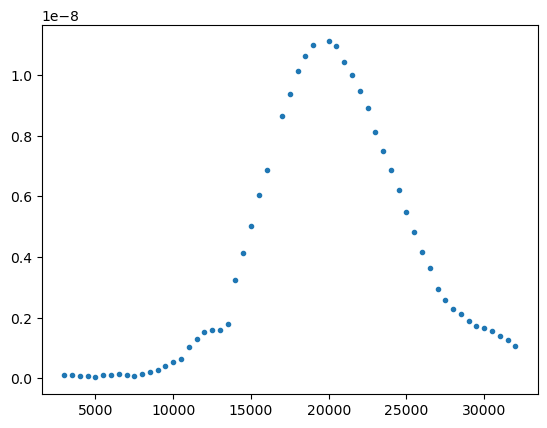

In [61]:
# Load and plot the raw data
df = pd.read_csv('SampleWienFilterData.txt')
x = df['# Velocity [m/s]']
y = df[' Current [A]']
plt.plot(x, y, '.')


In [113]:
# Assume a double Gaussian fit
def gaussian(x, A1, mu1, sigma1):
    gauss1 = A1 * np.exp(-0.5 * ((x - mu1) / sigma1)**2)
    return gauss1

def dual_gaussian(x, A1, mu1, sigma1, A2, mu2, sigma2, C):
    gauss1 = A1 * np.exp(-0.5 * ((x - mu1) / sigma1)**2)
    gauss2 = A2 * np.exp(-0.5 * ((x - mu2) / sigma2)**2)
    return gauss1 + gauss2 + C

def dual_gaussian_pm(x, A1, mu1, sigma1, A2, mu2, sigma2, C):
    gauss1 = A1 * pm.math.exp(-0.5 * pm.math.sqr((x - mu1) / sigma1))
    gauss2 = A2 * pm.math.exp(-0.5 * pm.math.sqr((x - mu2) / sigma2))
    return gauss1 + gauss2 + C

def triple_gaussian_pm(x, A1, mu1, sigma1, A2, mu2, sigma2, A3, mu3, sigma3, C):
    gauss1 = A1 * pm.math.exp(-0.5 * pm.math.sqr((x - mu1) / sigma1))
    gauss2 = A2 * pm.math.exp(-0.5 * pm.math.sqr((x - mu2) / sigma2))
    gauss3 = A3 * pm.math.exp(-0.5 * pm.math.sqr((x - mu3) / sigma3))
    return gauss1 + gauss2 + gauss3 + C

# Visualize the function to verify it's looks how we expect
#xs = np.linspace(0, 100, 100)
#plt.plot(xs, dual_gaussian(xs, 1, 30, 10, 1.2, 70, 10, 0))


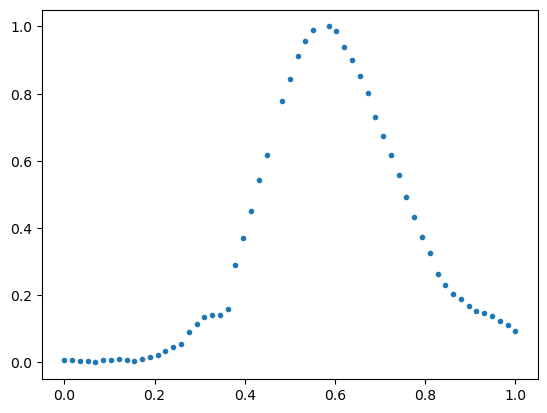

In [114]:
# Scale the data for numerical stability of MCMC
x_min, x_max = x.min(), x.max()
y_min, y_max = y.min(), y.max()

def minmax_scale(data, data_min, data_max):
    return (data - data_min) / (data_max - data_min)

def minmax_rescale(scaled_data, data_min, data_max):
    return scaled_data * (data_max - data_min) + data_min

# Scale
x_scaled = minmax_scale(x, x_min, x_max)
y_scaled = minmax_scale(y, y_min, y_max)

plt.plot(x_scaled, y_scaled, '.')

# Dual Gaussian Fit Attempts

In [96]:
# Model
with pm.Model() as model:
    """
    # Priors for the first Gaussian
    A1 = pm.Uniform("A1", lower=0, upper=0.1)
    mu1 = pm.Uniform("mu1", lower=0.2, upper=0.4)
    sigma1 = pm.HalfNormal("sigma1", sigma=0.1)

    # Priors for the second Gaussian
    A2 = pm.Uniform("A2", lower=0.5, upper=1.2)
    mu2 = pm.Uniform("mu2", lower=0.4, upper=0.8)
    sigma2 = pm.HalfNormal("sigma2", sigma=0.1)

    # Prior for vertical offset
    C = pm.HalfNormal("C", sigma=0.1)

    # Noise prior (optional)
    sigma_obs = pm.HalfNormal("sigma_obs", sigma=1)
    """
    # Priors for left-side (shoulder) Gaussian
    A1 = pm.TruncatedNormal("A1", mu=0.15, sigma=0.1, lower=0)
    mu1 = pm.Normal("mu1", mu=0.25, sigma=0.05)
    sigma1 = pm.HalfNormal("sigma1", sigma=0.07)
    
    # Priors for main peak Gaussian
    A2 = pm.TruncatedNormal("A2", mu=1.0, sigma=0.2, lower=0)
    mu2 = pm.Normal("mu2", mu=0.65, sigma=0.07)
    sigma2 = pm.HalfNormal("sigma2", sigma=0.08)
    # Optional: add a prior or constraint enforcing mu1 < mu2
    
    C = pm.Normal("C", mu=0, sigma=0.05)
    sigma_obs = pm.HalfNormal("sigma_obs", sigma=0.05)

    # Expected value
    x_shared = pt.as_tensor_variable(x_scaled)
    mu = dual_gaussian_pm(x_shared, A1, mu1, sigma1, A2, mu2, sigma2, C)
    
    # Likelihood (Normal likelihood for observed y)
    y_likelihood = pm.Normal("y_likelihood", mu=mu, sigma=sigma_obs, observed=y_scaled)

    # Perform the MCMC sampling
    trace = pm.sample(3000, tune=2000, target_accept=0.95, return_inferencedata=True)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [A1, mu1, sigma1, A2, mu2, sigma2, C, sigma_obs]


Output()

Sampling 4 chains for 2_000 tune and 3_000 draw iterations (8_000 + 12_000 draws total) took 225 seconds.


In [102]:
# Unscale y-domain parameters
A1_unscaled     = minmax_rescale(trace.posterior["A1"].values.flatten(), y_min, y_max)
A2_unscaled     = minmax_rescale(trace.posterior["A2"].values.flatten(), y_min, y_max)
C_unscaled      = minmax_rescale(trace.posterior["C"].values.flatten(), y_min, y_max)

# Unscale x-domain parameters
mu1_unscaled    = minmax_rescale(trace.posterior["mu1"].values.flatten(), x_min, x_max)
mu2_unscaled    = minmax_rescale(trace.posterior["mu2"].values.flatten(), x_min, x_max)
sigma1_unscaled = trace.posterior["sigma1"].values.flatten() * (x_max - x_min)
sigma2_unscaled = trace.posterior["sigma2"].values.flatten() * (x_max - x_min)

4.143724884144735e-09 7.681964747862999e-09 2.0884857679382583e-10
18425.400509007064 21137.91208825435
2629.937795316554 4381.491376714586


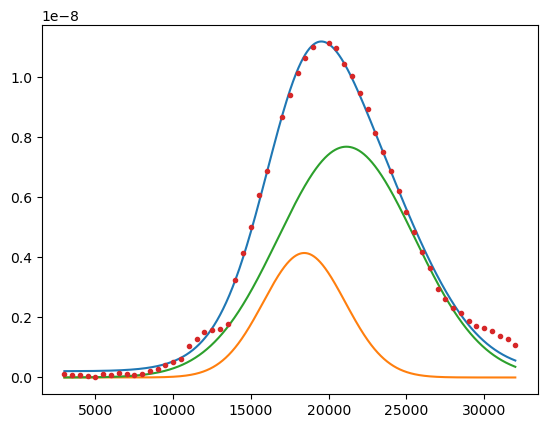

In [104]:
A1  = np.mean(A1_unscaled)
A2  = np.mean(A2_unscaled)
C   = np.mean(C_unscaled)
mu1 = np.mean(mu1_unscaled)
mu2 = np.mean(mu2_unscaled)
s1  = np.mean(sigma1_unscaled)
s2  = np.mean(sigma2_unscaled)

print(A1, A2, C)
print(mu1, mu2)
print(s1, s2)

plt.figure()
xs = np.linspace(3000, 32000, num=30000)
plt.plot(xs, dual_gaussian(xs, A1, mu1, s1, A2, mu2, s2, C))
plt.plot(xs, gaussian(xs, A1, mu1, s1))
plt.plot(xs, gaussian(xs, A2, mu2, s2))
plt.plot(x, y, '.')

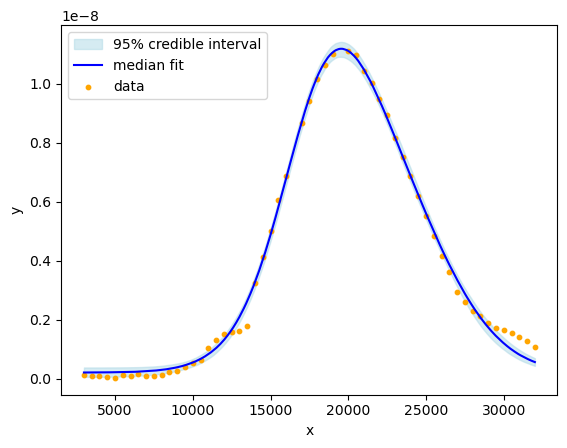

In [99]:
n_draws = 1000  # Or len(trace) for all samples
indices = np.random.choice(len(mu1_unscaled), n_draws, replace=False)

A1_draws = A1_unscaled[indices]
mu1_draws = mu1_unscaled[indices]
sigma1_draws = sigma1_unscaled[indices]
A2_draws = A2_unscaled[indices]
mu2_draws = mu2_unscaled[indices]
sigma2_draws = sigma2_unscaled[indices]
C_draws = C_unscaled[indices]

x_plot = np.linspace(x_min, x_max, 30000)
# Don't scale this x (keep in original units for plotting)
#x_scaled_plot = minmax_scale(x_plot, x_min, x_max)  # if your curve function expects scaled x

y_pred_curves = []
for i in range(n_draws):
    y_pred = dual_gaussian(
        x_plot, 
        A1_draws[i], mu1_draws[i], sigma1_draws[i], 
        A2_draws[i], mu2_draws[i], sigma2_draws[i], 
        C_draws[i]
    )
    y_pred_curves.append(y_pred)
y_pred_curves = np.array(y_pred_curves)  # shape (n_draws, len(x_plot))

y_lower = np.percentile(y_pred_curves, 2.5, axis=0)
y_upper = np.percentile(y_pred_curves, 97.5, axis=0)
y_median = np.percentile(y_pred_curves, 50, axis=0)  # or mean, or use your original curve

plt.figure()
plt.fill_between(x_plot, y_lower, y_upper, color='lightblue', alpha=0.5, label="95% credible interval")
plt.plot(x_plot, y_median, color='blue', label="median fit")
plt.scatter(x, y, color='orange', label="data", s=10)
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.show()

# Simple regression to see if the dual gaussian will even fit

[0.98075097 0.59198717 0.14429013]


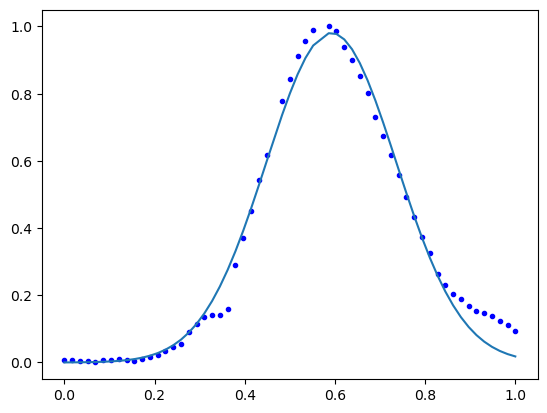

In [110]:
from scipy.optimize import curve_fit

params, cov = curve_fit(gaussian, x_scaled, y_scaled)
print(params)

plt.plot(x_scaled, y_scaled, 'b.')
plt.plot(x_scaled, gaussian(x_scaled, params[0], params[1], params[2]))

In [121]:
params, cov = curve_fit(dual_gaussian, x_scaled, y_scaled, maxfev = 10000)
print(params)

plt.plot(x_scaled, y_scaled, 'b.')
plt.plot(x_scaled, gaussian(x_scaled, params[0], params[1], params[2]))

RuntimeError: Optimal parameters not found: Number of calls to function has reached maxfev = 10000.

In [122]:
def triple_gaussian(x, A1, mu1, sigma1, A2, mu2, sigma2, A3, mu3, sigma3, C):
    gauss1 = A1 * np.exp(-0.5 * ((x - mu1) / sigma1)**2)
    gauss2 = A2 * np.exp(-0.5 * ((x - mu2) / sigma2)**2)
    gauss3 = A3 * np.exp(-0.5 * ((x - mu3) / sigma3)**2)
    return gauss1 + gauss2 + gauss3 + C

params, cov = curve_fit(triple_gaussian, x_scaled, y_scaled, maxfev=12000)

RuntimeError: Optimal parameters not found: Number of calls to function has reached maxfev = 12000.

# Let's see if MCMC can handle a triple Gaussian

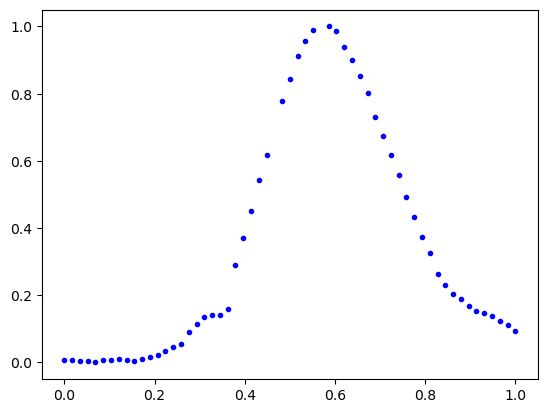

In [123]:
plt.plot(x_scaled, y_scaled, 'b.')

In [124]:
x_shared = pt.as_tensor_variable(x_scaled)

with pm.Model() as model:
    # Amplitudes
    A1 = pm.TruncatedNormal("A1", mu=0.15, sigma=0.10, lower=0)
    A2 = pm.TruncatedNormal("A2", mu=1.00, sigma=0.20, lower=0)
    A3 = pm.TruncatedNormal("A3", mu=0.15, sigma=0.10, lower=0)

    # Centers
    mu1 = pm.Normal("mu1", mu=0.22, sigma=0.06)
    mu2 = pm.Normal("mu2", mu=0.62, sigma=0.06)
    mu3 = pm.Normal("mu3", mu=0.82, sigma=0.06)

    # Widths
    sigma1 = pm.HalfNormal("sigma1", sigma=0.07)
    sigma2 = pm.HalfNormal("sigma2", sigma=0.08)
    sigma3 = pm.HalfNormal("sigma3", sigma=0.07)

    # Offset and noise
    C = pm.Normal("C", mu=0, sigma=0.05)
    sigma_obs = pm.HalfNormal("sigma_obs", sigma=0.05)

    # Model
    mu = triple_gaussian_pm(x_shared, A1, mu1, sigma1, A2, mu2, sigma2, A3, mu3, sigma3, C)
    y_like = pm.Normal("y_like", mu=mu, sigma=sigma_obs, observed=y_scaled)

    # Perform the MCMC sampling
    trace = pm.sample(3000, tune=2000, target_accept=0.95, return_inferencedata=True)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [A1, A2, A3, mu1, mu2, mu3, sigma1, sigma2, sigma3, C, sigma_obs]


Output()

Sampling 4 chains for 2_000 tune and 3_000 draw iterations (8_000 + 12_000 draws total) took 542 seconds.
There were 456 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


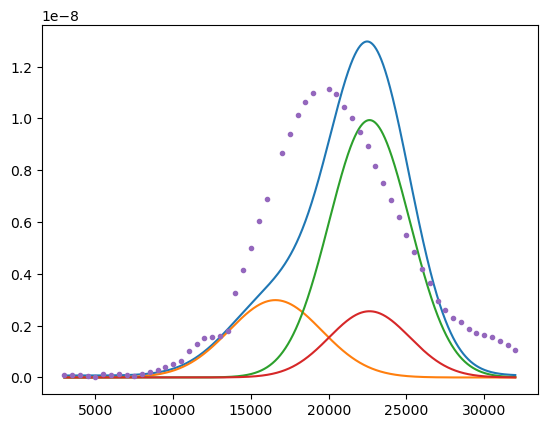

In [125]:
# Unscale y-domain parameters
A1_unscaled     = minmax_rescale(trace.posterior["A1"].values.flatten(), y_min, y_max)
A2_unscaled     = minmax_rescale(trace.posterior["A2"].values.flatten(), y_min, y_max)
A3_unscaled     = minmax_rescale(trace.posterior["A3"].values.flatten(), y_min, y_max)
C_unscaled      = minmax_rescale(trace.posterior["C"].values.flatten(), y_min, y_max)

# Unscale x-domain parameters
mu1_unscaled    = minmax_rescale(trace.posterior["mu1"].values.flatten(), x_min, x_max)
mu2_unscaled    = minmax_rescale(trace.posterior["mu2"].values.flatten(), x_min, x_max)
mu3_unscaled    = minmax_rescale(trace.posterior["mu2"].values.flatten(), x_min, x_max)
sigma1_unscaled = trace.posterior["sigma1"].values.flatten() * (x_max - x_min)
sigma2_unscaled = trace.posterior["sigma2"].values.flatten() * (x_max - x_min)
sigma3_unscaled = trace.posterior["sigma2"].values.flatten() * (x_max - x_min)

# Obtain means for plotting individual functions
A1  = np.mean(A1_unscaled); A2  = np.mean(A2_unscaled); A3  = np.mean(A3_unscaled)
C   = np.mean(C_unscaled)
mu1 = np.mean(mu1_unscaled); mu2 = np.mean(mu2_unscaled); mu3 = np.mean(mu3_unscaled)
s1  = np.mean(sigma1_unscaled); s2  = np.mean(sigma2_unscaled); s3  = np.mean(sigma3_unscaled)

plt.figure()
xs = np.linspace(3000, 32000, num=30000)
plt.plot(xs, triple_gaussian(xs, A1, mu1, s1, A2, mu2, s2, A3, mu3, s3, C))
plt.plot(xs, gaussian(xs, A1, mu1, s1))
plt.plot(xs, gaussian(xs, A2, mu2, s2))
plt.plot(xs, gaussian(xs, A3, mu3, s3))
plt.plot(x, y, '.')

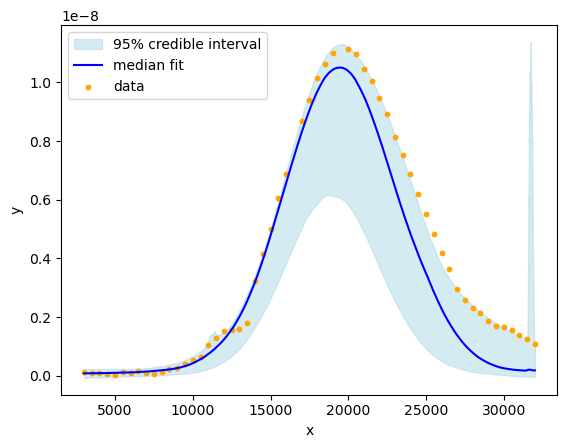

In [126]:
n_draws = 1000  # Or len(trace) for all samples
indices = np.random.choice(len(mu1_unscaled), n_draws, replace=False)

A1_draws = A1_unscaled[indices]
mu1_draws = mu1_unscaled[indices]
sigma1_draws = sigma1_unscaled[indices]
A2_draws = A2_unscaled[indices]
mu2_draws = mu2_unscaled[indices]
sigma2_draws = sigma2_unscaled[indices]
A3_draws = A3_unscaled[indices]
mu3_draws = mu3_unscaled[indices]
sigma3_draws = sigma3_unscaled[indices]
C_draws = C_unscaled[indices]

x_plot = np.linspace(x_min, x_max, 30000)
# Don't scale this x (keep in original units for plotting)
#x_scaled_plot = minmax_scale(x_plot, x_min, x_max)  # if your curve function expects scaled x

y_pred_curves = []
for i in range(n_draws):
    y_pred = dual_gaussian(
        x_plot, 
        A1_draws[i], mu1_draws[i], sigma1_draws[i], 
        A2_draws[i], mu2_draws[i], sigma2_draws[i], 
        C_draws[i]
    )
    y_pred_curves.append(y_pred)
y_pred_curves = np.array(y_pred_curves)  # shape (n_draws, len(x_plot))

y_lower = np.percentile(y_pred_curves, 2.5, axis=0)
y_upper = np.percentile(y_pred_curves, 97.5, axis=0)
y_median = np.percentile(y_pred_curves, 50, axis=0)  # or mean, or use your original curve

plt.figure()
plt.fill_between(x_plot, y_lower, y_upper, color='lightblue', alpha=0.5, label="95% credible interval")
plt.plot(x_plot, y_median, color='blue', label="median fit")
plt.scatter(x, y, color='orange', label="data", s=10)
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.show()

### Let's play with it by hand:

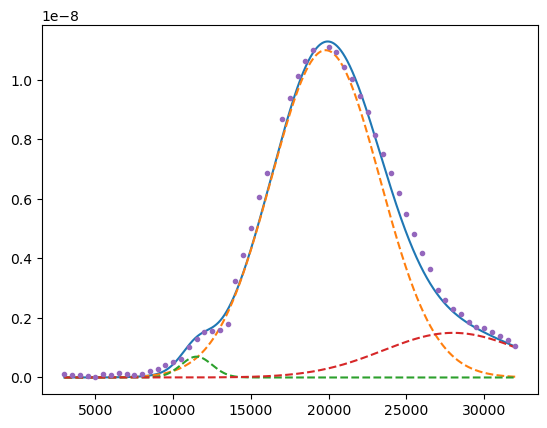

In [176]:
A1h = 1.1e-8
mu1h = 19800
s1h = 3500

A2h = 0.07e-8
mu2h = 11500
s2h = 1000

A3h = 0.15e-8
mu3h = 28000
s3h = 4500

Ch = 0

plt.figure()
xs = np.linspace(3000, 32000, num=30000)
plt.plot(xs, triple_gaussian(xs, A1h, mu1h, s1h, A2h, mu2h, s2h, A3h, mu3h, s3h, Ch))
plt.plot(xs, gaussian(xs, A1h, mu1h, s1h), '--')
plt.plot(xs, gaussian(xs, A2h, mu2h, s2h), '--')
plt.plot(xs, gaussian(xs, A3h, mu3h, s3h), '--')
plt.plot(x, y, '.')

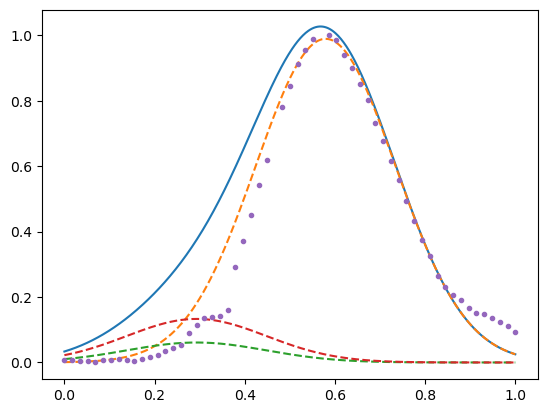

In [175]:
# My hand-tuned values, rescaled
A1h  = 1.1e-8; A1S = minmax_scale(A1h, y_min, y_max)
mu1h = 19800; mu1S = minmax_scale(mu1h, x_min, x_max)
s1h  = 3500;   s1S = s3h / (x_max - x_min)

A2h = 0.07e-8; A2S = minmax_scale(A2h, y_min, y_max)
mu2h = 11500; mu2S = minmax_scale(mu2h, x_min, x_max)
s2h = 1000;   s2S = s3h / (x_max - x_min)

A3h = 0.15e-8; A3S = minmax_scale(A3h, y_min, y_max)
mu3h = 28000; mu3S = minmax_scale(mu2h, x_min, x_max)
s3h = 4500;   s3S = s3h / (x_max - x_min)

CS = 0

plt.figure()
xs = np.linspace(0, 1, num=500)
plt.plot(xs, triple_gaussian(xs, A1S, mu1S, s1S, A2S, mu2S, s2S, A3S, mu3S, s3S, CS))
plt.plot(xs, gaussian(xs, A1S, mu1S, s1S), '--')
plt.plot(xs, gaussian(xs, A2S, mu2S, s2S), '--')
plt.plot(xs, gaussian(xs, A3S, mu3S, s3S), '--')
plt.plot(x_scaled, y_scaled, '.')

In [168]:


# Set moderate prior stddevs for each param
prior_frac = 0.25  # fraction of hand-tuned values to use as sigma for amplitudes/sigmas

x_shared = pt.as_tensor_variable(x_scaled)

with pm.Model() as model:
    # Amplitudes
    A1 = pm.TruncatedNormal("A1", mu=A1S, sigma=A1S*prior_frac, lower=0)
    A2 = pm.TruncatedNormal("A2", mu=A2S, sigma=max(A2S*prior_frac, 0.01e-8), lower=0)
    A3 = pm.TruncatedNormal("A3", mu=A3S, sigma=A3S*prior_frac, lower=0)

    # Means
    mu1 = pm.Normal("mu1", mu=mu1S, sigma=1000)
    mu2 = pm.Normal("mu2", mu=mu2S, sigma=500)
    mu3 = pm.Normal("mu3", mu=mu3S, sigma=1000)

    # Widths
    sigma1 = pm.HalfNormal("sigma1", sigma=s1S*prior_frac)
    sigma2 = pm.HalfNormal("sigma2", sigma=s2S*prior_frac)
    sigma3 = pm.HalfNormal("sigma3", sigma=s3S*prior_frac)

    # Offset (centered, but can adjust)
    C = pm.Normal("C", mu=CS, sigma=0.01*A1S)

    # Noise (can guess by hand, or use HalfNormal)
    sigma_obs = pm.HalfNormal("sigma_obs", sigma=0.1 * A1S)

    mu = triple_gaussian(x_shared, A1, mu1, sigma1, A2, mu2, sigma2, A3, mu3, sigma3, C)
    y_likelihood = pm.Normal("y_likelihood", mu=mu, sigma=sigma_obs, observed=y)

    # Dict of initial values (helps sampler start off right)
    initvals = {
        "A1": A1S,
        "A2": A2S,
        "A3": A3S,
        "mu1": mu1S,
        "mu2": mu2S,
        "mu3": mu3S,
        "sigma1": s1S,
        "sigma2": s2S,
        "sigma3": s3S,
        "C": CS
    }

    trace = pm.sample(2000, tune=1000, initvals=initvals, target_accept=0.95, return_inferencedata=True)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...


SamplingError: Initial evaluation of model at starting point failed!
Starting values:
{'A1_interval__': array(0.02523711), 'A2_interval__': array(-3.00474141), 'A3_interval__': array(-1.90250513), 'mu1': array(-0.30440583), 'mu2': array(-0.69575945), 'mu3': array(-0.62019259), 'sigma1_log__': array(-3.31553491), 'sigma2_log__': array(nan), 'sigma3_log__': array(-3.28067933), 'C': array(-0.59873653), 'sigma_obs_log__': array(-2.58328515)}

Logp initial evaluation results:
{'A1': 0.49, 'A2': -0.02, 'A3': 0.46, 'mu1': -7.83, 'mu2': -7.13, 'mu3': -7.83, 'sigma1': -33.58, 'sigma2': nan, 'sigma3': -3.39, 'C': -1827.83, 'sigma_obs': -0.79, 'y_likelihood': nan}
You can call `model.debug()` for more details.

In [ ]:
# Unscale y-domain parameters
A1_unscaled     = minmax_rescale(trace.posterior["A1"].values.flatten(), y_min, y_max)
A2_unscaled     = minmax_rescale(trace.posterior["A2"].values.flatten(), y_min, y_max)
A3_unscaled     = minmax_rescale(trace.posterior["A3"].values.flatten(), y_min, y_max)
C_unscaled      = minmax_rescale(trace.posterior["C"].values.flatten(), y_min, y_max)

# Unscale x-domain parameters
mu1_unscaled    = minmax_rescale(trace.posterior["mu1"].values.flatten(), x_min, x_max)
mu2_unscaled    = minmax_rescale(trace.posterior["mu2"].values.flatten(), x_min, x_max)
mu3_unscaled    = minmax_rescale(trace.posterior["mu2"].values.flatten(), x_min, x_max)
sigma1_unscaled = trace.posterior["sigma1"].values.flatten() * (x_max - x_min)
sigma2_unscaled = trace.posterior["sigma2"].values.flatten() * (x_max - x_min)
sigma3_unscaled = trace.posterior["sigma2"].values.flatten() * (x_max - x_min)

# Obtain means for plotting individual functions
A1  = np.mean(A1_unscaled); A2  = np.mean(A2_unscaled); A3  = np.mean(A3_unscaled)
C   = np.mean(C_unscaled)
mu1 = np.mean(mu1_unscaled); mu2 = np.mean(mu2_unscaled); mu3 = np.mean(mu3_unscaled)
s1  = np.mean(sigma1_unscaled); s2  = np.mean(sigma2_unscaled); s3  = np.mean(sigma3_unscaled)

plt.figure()
xs = np.linspace(3000, 32000, num=30000)
plt.plot(xs, triple_gaussian(xs, A1, mu1, s1, A2, mu2, s2, A3, mu3, s3, C))
plt.plot(xs, gaussian(xs, A1, mu1, s1), '--')
plt.plot(xs, gaussian(xs, A2, mu2, s2), '--')
plt.plot(xs, gaussian(xs, A3, mu3, s3), '--')
plt.plot(x, y, '.')

In [ ]:
n_draws = 1000  # Or len(trace) for all samples
indices = np.random.choice(len(mu1_unscaled), n_draws, replace=False)

A1_draws = A1_unscaled[indices]
mu1_draws = mu1_unscaled[indices]
sigma1_draws = sigma1_unscaled[indices]
A2_draws = A2_unscaled[indices]
mu2_draws = mu2_unscaled[indices]
sigma2_draws = sigma2_unscaled[indices]
A3_draws = A3_unscaled[indices]
mu3_draws = mu3_unscaled[indices]
sigma3_draws = sigma3_unscaled[indices]
C_draws = C_unscaled[indices]

x_plot = np.linspace(x_min, x_max, 30000)
# Don't scale this x (keep in original units for plotting)
#x_scaled_plot = minmax_scale(x_plot, x_min, x_max)  # if your curve function expects scaled x

y_pred_curves = []
for i in range(n_draws):
    y_pred = dual_gaussian(
        x_plot, 
        A1_draws[i], mu1_draws[i], sigma1_draws[i], 
        A2_draws[i], mu2_draws[i], sigma2_draws[i], 
        C_draws[i]
    )
    y_pred_curves.append(y_pred)
y_pred_curves = np.array(y_pred_curves)  # shape (n_draws, len(x_plot))

y_lower = np.percentile(y_pred_curves, 2.5, axis=0)
y_upper = np.percentile(y_pred_curves, 97.5, axis=0)
y_median = np.percentile(y_pred_curves, 50, axis=0)  # or mean, or use your original curve

plt.figure()
plt.fill_between(x_plot, y_lower, y_upper, color='lightblue', alpha=0.5, label="95% credible interval")
plt.plot(x_plot, y_median, color='blue', label="median fit")
plt.scatter(x, y, color='orange', label="data", s=10)
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.show()